In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Styling for publication-quality plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

H5_PATH = "../outputs/master_grid_data.h5"
SIGMA_SB = 5.670374419e-8

In [3]:
def build_catalog(h5_path):
    """Extracts scalar parameters from all models into a searchable DataFrame."""
    records = []
    
    with h5py.File(h5_path, 'r') as f:
        for model_id in f.keys():
            model_grp = f[model_id]
            
            if 'parameters' not in model_grp:
                continue
                
            # Extract all scalar attributes from the parameters group
            params = dict(model_grp['parameters'].attrs)
            params['model_id'] = model_id
            
            # Extract some key physical results for quick reference
            if 'interior_raw' in model_grp:
                params['R_total_Re'] = model_grp['interior_raw'].attrs.get('R_total', np.nan) / 6357000.0
                params['actual_T_int'] = model_grp['parameters'].attrs.get('T_int', np.nan)
                
            records.append(params)
            
    return pd.DataFrame(records)

# Build the catalog
df_catalog = build_catalog(H5_PATH)
print(f"Loaded {len(df_catalog)} models into the catalog.")
df_catalog.head()

Loaded 6414 models into the catalog.


,Met,T_int,T_int_input_dial,T_irr,Y_ratio,core_mass_earth,debug,f_sed,g_1bar,iron_fraction,kzz,mass,p_link_bar,true_mass_Mjup,z_base,model_id,R_total_Re,actual_T_int
0,-2.0,928.111622,1200.0,1000.0,0.250014,10.0,False,3.0,5.322498,0.33,8.0,0.3,15.848932,0.033298,0.003222,model_00010,3.794650,928.111622
1,0.0,120.464721,100.0,1000.0,0.250428,10.0,False,2.0,6.282797,0.33,8.0,0.3,1000.000000,0.034819,0.014938,model_00011,4.163089,120.464721
2,1.0,155.725727,200.0,500.0,0.250962,10.0,False,2.0,4.629820,0.33,8.0,0.3,273.841963,0.034767,0.116228,model_00012,4.809135,155.725727
3,1.0,156.327644,200.0,500.0,0.250962,10.0,False,2.0,4.692421,0.33,8.0,0.3,273.841963,0.034830,0.116226,model_00013,4.817323,156.327644
4,1.0,156.795196,200.0,500.0,0.250957,10.0,False,2.0,4.753315,0.33,8.0,0.3,273.841963,0.035035,0.116227,model_00014,4.822796,156.795196


In [5]:
import h5py
import numpy as np
import pandas as pd

SIGMA_SB = 5.670374419e-8
H5_PATH = "../outputs/master_grid_data.h5"

def regenerate_df_valid(h5_path, p_threshold_bar=10.0):
    """
    Re-evaluates the grid to calculate the old T_int and the new robust 
    RCB Sniper T_int, creating the Delta_T_int column required for plotting.
    """
    records = []
    
    with h5py.File(h5_path, 'r') as f:
        for model_id in f.keys():
            if f"{model_id}/atmosphere_raw" not in f or f"{model_id}/parameters" not in f:
                continue
                
            atm_grp = f[f"{model_id}/atmosphere_raw"]
            if '_outputs_levels_is_convective' not in atm_grp:
                continue
                
            p_bar = atm_grp['_outputs_levels_pressure'][:] / 1e5
            rad_int = atm_grp['_outputs_levels_radiosity_internal'][:]
            is_conv = atm_grp['_outputs_levels_is_convective'][:]
            
            # --- 1. Old Blanket Average ---
            p_mask = p_bar >= p_threshold_bar
            old_t_int = np.nan
            if np.any(p_mask):
                old_flux = np.nanmean(rad_int[p_mask])
                if old_flux > 0:
                    old_t_int = (old_flux / SIGMA_SB)**0.25
            
            # --- 2. New RCB Sniper ---
            new_t_int = np.nan
            idx = len(is_conv) - 1
            
            # Skip bottom artifacts
            while idx >= 0 and is_conv[idx] == 0: idx -= 1
            
            if idx >= 0:
                # Climb through convective zone
                while idx >= 0 and is_conv[idx] == 1: idx -= 1
                
                # Check clear space and extract flux
                if idx >= 0 and p_bar[idx] >= p_threshold_bar:
                    rcb_flux = np.nanmean(rad_int[max(0, idx-2) : idx+1])
                    if rcb_flux > 0:
                        new_t_int = (rcb_flux / SIGMA_SB)**0.25
                        
            params = f[model_id]['parameters'].attrs
            
            records.append({
                'model_id': model_id,
                'T_dial': params.get('T_int_input_dial', np.nan),
                'T_int_old': old_t_int,
                'T_int_new': new_t_int,
                'Delta_T_int': new_t_int - old_t_int if not np.isnan(new_t_int) and not np.isnan(old_t_int) else np.nan
            })
            
    return pd.DataFrame(records)

# Generate the dataframe and drop any rows that failed to evaluate
print("Sweeping HDF5 grid to recalculate T_int discrepancies...")
df_valid = regenerate_df_valid(H5_PATH).dropna(subset=['Delta_T_int'])
print(f"✅ Successfully recreated df_valid with {len(df_valid)} models!")

Sweeping HDF5 grid to recalculate T_int discrepancies...


/tmp/ipykernel_312623/3669152055.py:32: RuntimeWarning: Mean of empty slice
  old_flux = np.nanmean(rad_int[p_mask])
/tmp/ipykernel_312623/3669152055.py:49: RuntimeWarning: Mean of empty slice
  rcb_flux = np.nanmean(rad_int[max(0, idx-2) : idx+1])


✅ Successfully recreated df_valid with 5155 models!


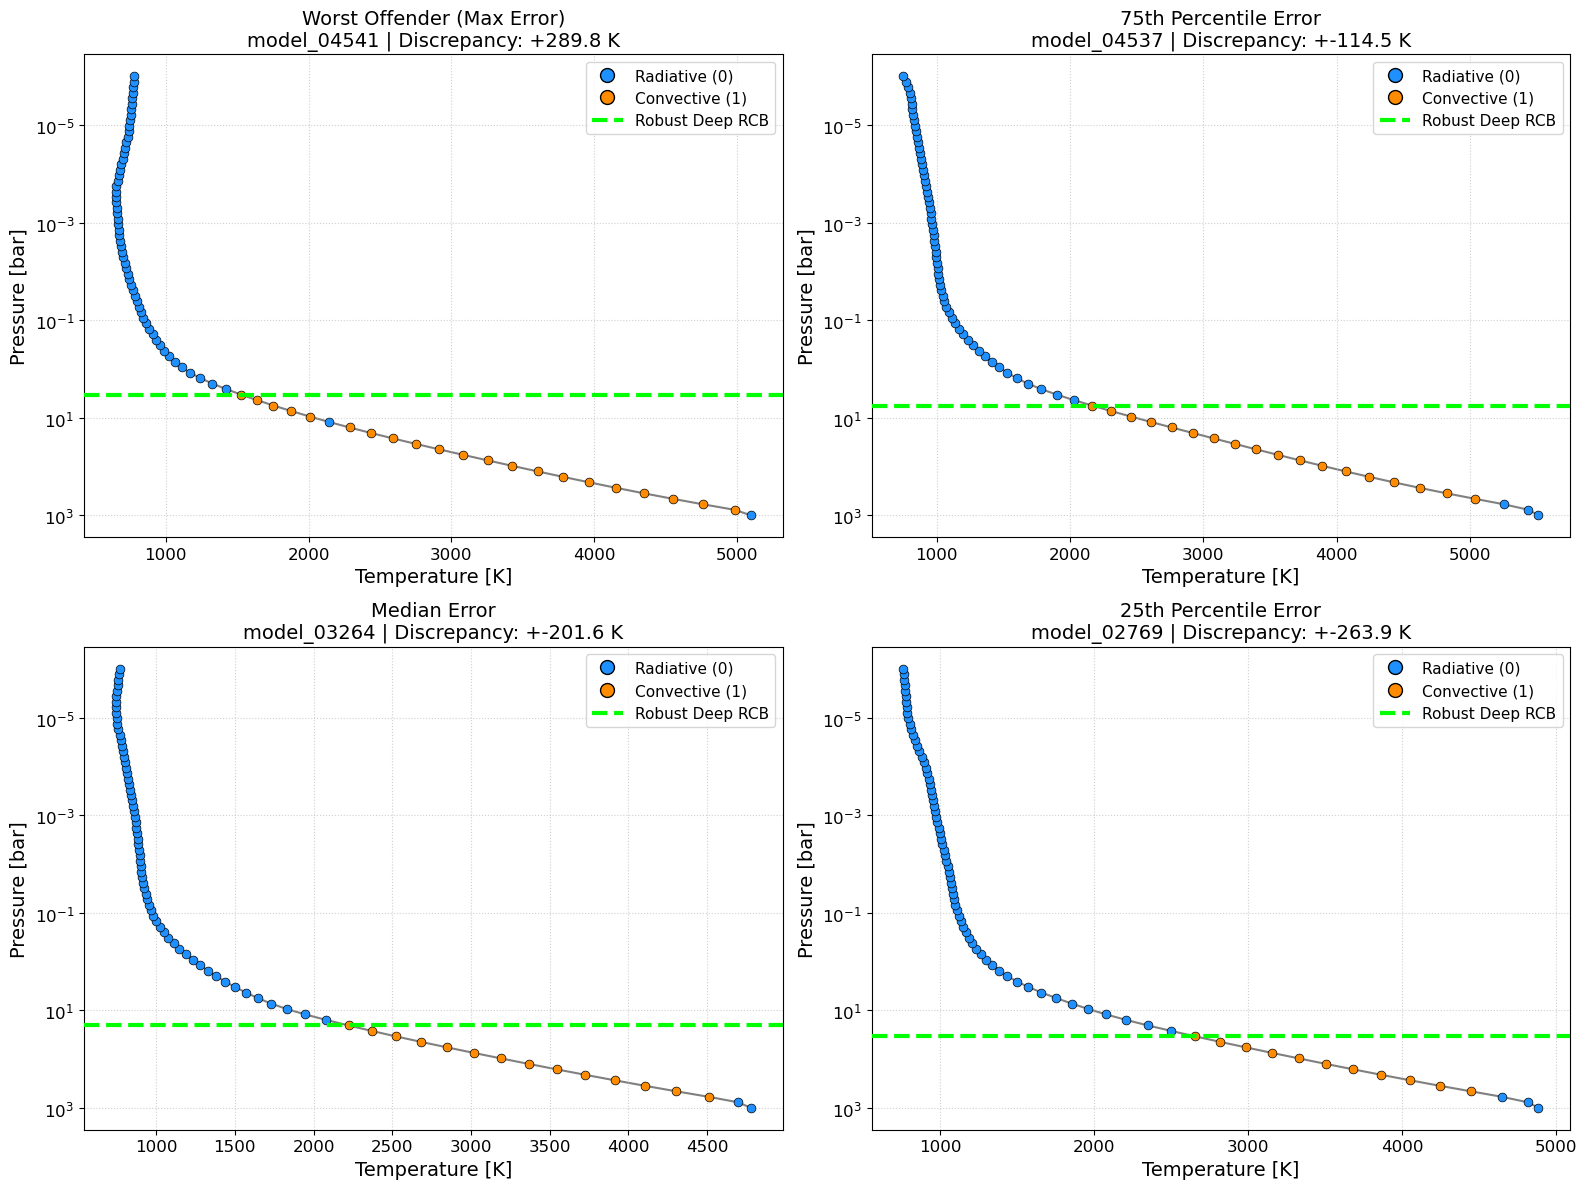

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def find_true_deep_rcb(is_conv_array, p_bar_array, p_threshold_bar=10.0, clear_space=3):
    """
    Direction-agnostic, robust scanner to find the True Deep RCB.
    Dynamically determines array orientation (Top-Down vs Bottom-Up), 
    skips boundary artifacts, and requires a 'clear space' to avoid blips.
    """
    # 1. Check if the deep atmosphere is ALREADY purely radiative
    p_mask = p_bar_array >= p_threshold_bar
    if np.any(p_mask) and np.all(is_conv_array[p_mask] == 0):
        return np.max(p_bar_array[p_mask])

    # 2. Dynamically find the bottom and the direction of "Up"
    bottom_idx = np.argmax(p_bar_array)
    step = 1 if bottom_idx == 0 else -1
    
    idx = bottom_idx
    n_layers = len(is_conv_array)
    
    def is_valid(i):
        return 0 <= i < n_layers
    
    while is_valid(idx):
        # 3. Skip artificial '0's at the very bottom boundary
        while is_valid(idx) and is_conv_array[idx] == 0:
            idx += step
            
        if not is_valid(idx): break
            
        # 4. Move up through the active convective zone ('1's)
        while is_valid(idx) and is_conv_array[idx] == 1:
            idx += step
            
        if not is_valid(idx): break
            
        # 5. We hit a '0'. Check for a CLEAR SPACE of '0's above it.
        # Slice the block based on our current direction
        if step == 1:
            # Array goes Bottom -> Top (index increases as we go up)
            block = is_conv_array[idx : min(idx + clear_space, n_layers)]
        else:
            # Array goes Top -> Bottom (index decreases as we go up)
            block = is_conv_array[max(0, idx - clear_space + 1) : idx + 1]
            
        if np.all(block == 0):
            # Success! The layer exactly one step BACK from our current position was the RCB.
            return p_bar_array[idx - step]
        else:
            # Just a thin blip. The while loop will continue upward.
            pass

    return np.nan

def plot_tp_with_convective_flag_robust(h5_path, df, p_threshold_bar=10.0):
    """
    Plots the Atmospheric T-P profile, colors the points by the 'is_convective' 
    flag, and draws the dynamically extracted True RCB using the 'Clear Space' logic.
    """
    df_sorted = df.sort_values(by='Delta_T_int', ascending=False).reset_index(drop=True)
    n_models = len(df_sorted)
    
    indices_to_plot = [
        0,                  # Worst Offender (Max Error)
        n_models // 4,      # 75th percentile
        n_models // 2,      # 50th percentile
        (n_models * 3) // 4 # 25th percentile
    ]
    
    labels = ["Worst Offender (Max Error)", "75th Percentile Error", "Median Error", "25th Percentile Error"]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    with h5py.File(h5_path, 'r') as f:
        for i, idx in enumerate(indices_to_plot):
            ax = axes[i]
            row = df_sorted.iloc[idx]
            model_id = row['model_id']
            delta_t = row['Delta_T_int']
            
            if f"{model_id}/atmosphere_raw" in f:
                atm_grp = f[f"{model_id}/atmosphere_raw"]
                
                p_bar = atm_grp['_outputs_levels_pressure'][:] / 1e5
                t_k = atm_grp['_outputs_levels_temperature'][:]
                is_conv = atm_grp['_outputs_levels_is_convective'][:]
                
                # Apply the new ROBUST bottom-up sniper logic
                p_rcb = find_true_deep_rcb(is_conv, p_bar, p_threshold_bar=p_threshold_bar, clear_space=3)
                
                ax.plot(t_k, p_bar, color='gray', lw=1.5, zorder=1)
                
                rad_mask = (is_conv == 0)
                conv_mask = (is_conv == 1)
                
                # Radiative (Blue) and Convective (Orange) scatter overlay
                ax.scatter(t_k[rad_mask], p_bar[rad_mask], color='dodgerblue', s=40, zorder=2, edgecolors='k', linewidths=0.5)
                ax.scatter(t_k[conv_mask], p_bar[conv_mask], color='darkorange', s=40, zorder=3, edgecolors='k', linewidths=0.5)
                
                # Draw the True RCB line
                if not np.isnan(p_rcb):
                    ax.axhline(p_rcb, color='lime', linestyle='--', lw=3, zorder=4)

                ax.set_yscale('log')
                ax.invert_yaxis()
                ax.set_xlabel("Temperature [K]", fontsize=14)
                ax.set_ylabel("Pressure [bar]", fontsize=14)
                
                ax.set_title(f"{labels[i]}\n{model_id} | Discrepancy: +{delta_t:.1f} K", fontsize=14)
                ax.grid(True, linestyle=':', alpha=0.6)
                
                custom_lines = [
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue', markersize=10, markeredgecolor='k', label='Radiative (0)'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, markeredgecolor='k', label='Convective (1)'),
                    Line2D([0], [0], color='lime', lw=3, linestyle='--', label='Robust Deep RCB')
                ]
                ax.legend(handles=custom_lines, fontsize=11, loc='best')
            else:
                ax.set_title(f"Model: {model_id} (Missing Data)")
                ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the updated plotting script
plot_tp_with_convective_flag_robust(H5_PATH, df_valid)

Scanning grid to extract Truth metrics...


/tmp/ipykernel_312623/1869015728.py:80: RuntimeWarning: Mean of empty slice
  rcb_flux = np.nanmean(rad_int[slice_indices])


✅ Evaluated 6389 models for the Truth Plot.


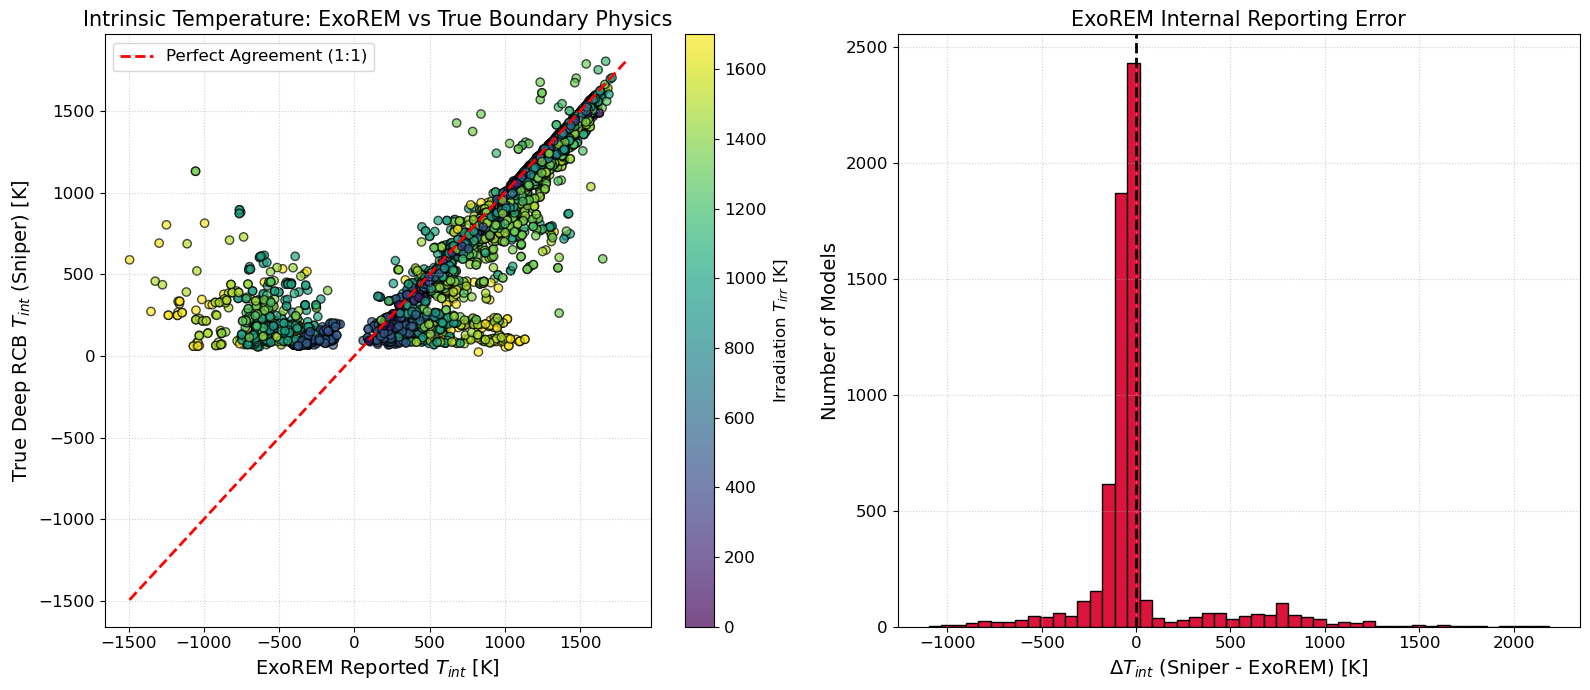

Mean Discrepancy: 1.95 K
Max Underestimation by ExoREM: 2187.18 K
Max Overestimation by ExoREM: -1099.26 K


In [8]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIGMA_SB = 5.670374419e-8
H5_PATH = "../outputs/master_grid_data.h5"

def find_true_deep_rcb(is_conv_array, p_bar_array, p_threshold_bar=10.0, clear_space=3):
    """Direction-agnostic, robust scanner to find the True Deep RCB."""
    p_mask = p_bar_array >= p_threshold_bar
    if np.any(p_mask) and np.all(is_conv_array[p_mask] == 0):
        return np.max(p_bar_array[p_mask])

    bottom_idx = np.argmax(p_bar_array)
    step = 1 if bottom_idx == 0 else -1
    
    idx = bottom_idx
    n_layers = len(is_conv_array)
    
    def is_valid(i): return 0 <= i < n_layers
    
    while is_valid(idx):
        while is_valid(idx) and is_conv_array[idx] == 0: idx += step
        if not is_valid(idx): break
        while is_valid(idx) and is_conv_array[idx] == 1: idx += step
        if not is_valid(idx): break
            
        if step == 1:
            block = is_conv_array[idx : min(idx + clear_space, n_layers)]
        else:
            block = is_conv_array[max(0, idx - clear_space + 1) : idx + 1]
            
        if np.all(block == 0):
            return p_bar_array[idx - step]
        else:
            pass
    return np.nan

def evaluate_truth_plot_data(h5_path, p_threshold_bar=10.0):
    """
    Sweeps the grid to compare the True RCB Sniper T_int against 
    ExoREM's self-reported 'actual_internal_temperature'.
    """
    records = []
    
    with h5py.File(h5_path, 'r') as f:
        for model_id in f.keys():
            if f"{model_id}/atmosphere_raw" not in f or f"{model_id}/parameters" not in f:
                continue
                
            atm_grp = f[f"{model_id}/atmosphere_raw"]
            if '_outputs_levels_is_convective' not in atm_grp or '_outputs_run_quality_actual_internal_temperature' not in atm_grp:
                continue
                
            p_bar = atm_grp['_outputs_levels_pressure'][:] / 1e5
            rad_int = atm_grp['_outputs_levels_radiosity_internal'][:]
            is_conv = atm_grp['_outputs_levels_is_convective'][:]
            
            # 1. ExoREM's self-reported T_int
            t_int_exorem = atm_grp['_outputs_run_quality_actual_internal_temperature'][0]
            
            # 2. Our Robust RCB Sniper T_int
            new_t_int = np.nan
            p_rcb = find_true_deep_rcb(is_conv, p_bar, p_threshold_bar)
            
            if not np.isnan(p_rcb):
                # Find the exact array index of the RCB
                idx_rcb = np.argmin(np.abs(p_bar - p_rcb))
                
                # Average the flux in the 3 clear radiative layers immediately above the RCB
                bottom_idx = np.argmax(p_bar)
                step = 1 if bottom_idx == 0 else -1
                
                if step == 1:
                    slice_indices = list(range(idx_rcb, min(idx_rcb + 3, len(p_bar))))
                else:
                    slice_indices = list(range(max(0, idx_rcb - 2), idx_rcb + 1))
                
                rcb_flux = np.nanmean(rad_int[slice_indices])
                if rcb_flux > 0:
                    new_t_int = (rcb_flux / SIGMA_SB)**0.25
            
            params = f[model_id]['parameters'].attrs
            records.append({
                'model_id': model_id,
                'T_irr': params.get('T_irr', np.nan),
                'T_int_exorem': t_int_exorem,
                'T_int_rcb': new_t_int,
                'Delta_T': new_t_int - t_int_exorem if not np.isnan(new_t_int) else np.nan
            })
            
    return pd.DataFrame(records)

# 1. Generate the DataFrame
print("Scanning grid to extract Truth metrics...")
df_truth = evaluate_truth_plot_data(H5_PATH)
df_valid_truth = df_truth.dropna(subset=['T_int_exorem', 'T_int_rcb']).copy()
print(f"✅ Evaluated {len(df_valid_truth)} models for the Truth Plot.")

# 2. Plotting the Truth Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: The Truth Scatter ---
sc = ax1.scatter(
    df_valid_truth['T_int_exorem'], 
    df_valid_truth['T_int_rcb'], 
    c=df_valid_truth['T_irr'], 
    cmap='viridis', 
    alpha=0.7, 
    edgecolor='k'
)

# Draw the 1:1 perfect agreement line
max_val = max(df_valid_truth['T_int_exorem'].max(), df_valid_truth['T_int_rcb'].max())
min_val = min(df_valid_truth['T_int_exorem'].min(), df_valid_truth['T_int_rcb'].min())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Agreement (1:1)')

ax1.set_xlabel(r"ExoREM Reported $T_{int}$ [K]", fontsize=14)
ax1.set_ylabel(r"True Deep RCB $T_{int}$ (Sniper) [K]", fontsize=14)
ax1.set_title("Intrinsic Temperature: ExoREM vs True Boundary Physics", fontsize=15)
ax1.legend(fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label(r"Irradiation $T_{irr}$ [K]", fontsize=12)

# --- Plot 2: Histogram of Discrepancies ---
ax2.hist(df_valid_truth['Delta_T'], bins=50, color='crimson', edgecolor='black')
ax2.axvline(0, color='k', linestyle='--', lw=2)

ax2.set_xlabel(r"$\Delta T_{int}$ (Sniper - ExoREM) [K]", fontsize=14)
ax2.set_ylabel("Number of Models", fontsize=14)
ax2.set_title("ExoREM Internal Reporting Error", fontsize=15)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Print quick statistics
mean_err = df_valid_truth['Delta_T'].mean()
max_err = df_valid_truth['Delta_T'].max()
min_err = df_valid_truth['Delta_T'].min()
print(f"Mean Discrepancy: {mean_err:.2f} K")
print(f"Max Underestimation by ExoREM: {max_err:.2f} K")
print(f"Max Overestimation by ExoREM: {min_err:.2f} K")

Scanning grid to extract Dial vs Truth metrics...


/tmp/ipykernel_312623/2262670734.py:78: RuntimeWarning: Mean of empty slice
  rcb_flux = np.nanmean(rad_int[slice_indices])


✅ Evaluated 6389 models for the Dial Plot.


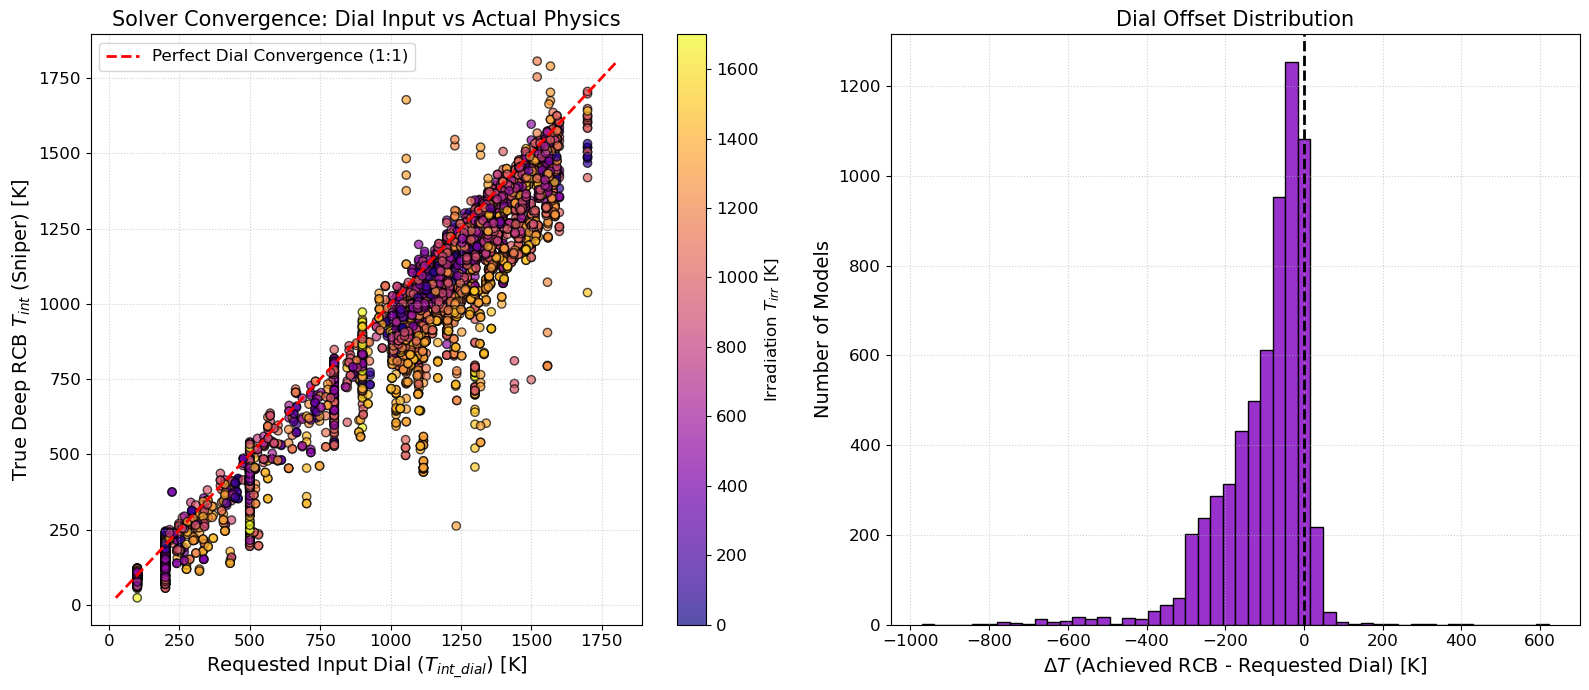

Mean Convergence Offset: -98.63 K
Max Overshoot (Achieved > Dial): 621.49 K
Max Undershoot (Achieved < Dial): -971.00 K


In [9]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIGMA_SB = 5.670374419e-8
H5_PATH = "../outputs/master_grid_data.h5"

def find_true_deep_rcb(is_conv_array, p_bar_array, p_threshold_bar=10.0, clear_space=3):
    """Direction-agnostic, robust scanner to find the True Deep RCB."""
    p_mask = p_bar_array >= p_threshold_bar
    if np.any(p_mask) and np.all(is_conv_array[p_mask] == 0):
        return np.max(p_bar_array[p_mask])

    bottom_idx = np.argmax(p_bar_array)
    step = 1 if bottom_idx == 0 else -1
    
    idx = bottom_idx
    n_layers = len(is_conv_array)
    
    def is_valid(i): return 0 <= i < n_layers
    
    while is_valid(idx):
        while is_valid(idx) and is_conv_array[idx] == 0: idx += step
        if not is_valid(idx): break
        while is_valid(idx) and is_conv_array[idx] == 1: idx += step
        if not is_valid(idx): break
            
        if step == 1:
            block = is_conv_array[idx : min(idx + clear_space, n_layers)]
        else:
            block = is_conv_array[max(0, idx - clear_space + 1) : idx + 1]
            
        if np.all(block == 0):
            return p_bar_array[idx - step]
        else:
            pass
    return np.nan

def evaluate_dial_truth(h5_path, p_threshold_bar=10.0):
    """
    Sweeps the grid to compare the True RCB Sniper T_int against 
    the requested input dial T_int.
    """
    records = []
    
    with h5py.File(h5_path, 'r') as f:
        for model_id in f.keys():
            if f"{model_id}/atmosphere_raw" not in f or f"{model_id}/parameters" not in f:
                continue
                
            atm_grp = f[f"{model_id}/atmosphere_raw"]
            if '_outputs_levels_is_convective' not in atm_grp:
                continue
                
            p_bar = atm_grp['_outputs_levels_pressure'][:] / 1e5
            rad_int = atm_grp['_outputs_levels_radiosity_internal'][:]
            is_conv = atm_grp['_outputs_levels_is_convective'][:]
            params = f[model_id]['parameters'].attrs
            
            # 1. The Requested Input Dial T_int
            t_dial = params.get('T_int_input_dial', np.nan)
            
            # 2. Our Robust RCB Sniper T_int
            new_t_int = np.nan
            p_rcb = find_true_deep_rcb(is_conv, p_bar, p_threshold_bar)
            
            if not np.isnan(p_rcb):
                idx_rcb = np.argmin(np.abs(p_bar - p_rcb))
                bottom_idx = np.argmax(p_bar)
                step = 1 if bottom_idx == 0 else -1
                
                if step == 1:
                    slice_indices = list(range(idx_rcb, min(idx_rcb + 3, len(p_bar))))
                else:
                    slice_indices = list(range(max(0, idx_rcb - 2), idx_rcb + 1))
                
                rcb_flux = np.nanmean(rad_int[slice_indices])
                if rcb_flux > 0:
                    new_t_int = (rcb_flux / SIGMA_SB)**0.25
            
            records.append({
                'model_id': model_id,
                'T_irr': params.get('T_irr', np.nan),
                'T_dial': t_dial,
                'T_int_rcb': new_t_int,
                'Delta_Dial': new_t_int - t_dial if not np.isnan(new_t_int) else np.nan
            })
            
    return pd.DataFrame(records)

# 1. Generate the DataFrame
print("Scanning grid to extract Dial vs Truth metrics...")
df_dial = evaluate_dial_truth(H5_PATH)
df_valid_dial = df_dial.dropna(subset=['T_dial', 'T_int_rcb']).copy()
print(f"✅ Evaluated {len(df_valid_dial)} models for the Dial Plot.")

# 2. Plotting the Dial Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: The Truth Scatter ---
sc = ax1.scatter(
    df_valid_dial['T_dial'], 
    df_valid_dial['T_int_rcb'], 
    c=df_valid_dial['T_irr'], 
    cmap='plasma', 
    alpha=0.7, 
    edgecolor='k'
)

# Draw the 1:1 perfect agreement line
max_val = max(df_valid_dial['T_dial'].max(), df_valid_dial['T_int_rcb'].max())
min_val = min(df_valid_dial['T_dial'].min(), df_valid_dial['T_int_rcb'].min())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Dial Convergence (1:1)')

ax1.set_xlabel(r"Requested Input Dial ($T_{int\_dial}$) [K]", fontsize=14)
ax1.set_ylabel(r"True Deep RCB $T_{int}$ (Sniper) [K]", fontsize=14)
ax1.set_title("Solver Convergence: Dial Input vs Actual Physics", fontsize=15)
ax1.legend(fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label(r"Irradiation $T_{irr}$ [K]", fontsize=12)

# --- Plot 2: Histogram of Discrepancies ---
ax2.hist(df_valid_dial['Delta_Dial'], bins=50, color='darkorchid', edgecolor='black')
ax2.axvline(0, color='k', linestyle='--', lw=2)

ax2.set_xlabel(r"$\Delta T$ (Achieved RCB - Requested Dial) [K]", fontsize=14)
ax2.set_ylabel("Number of Models", fontsize=14)
ax2.set_title("Dial Offset Distribution", fontsize=15)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Print quick statistics
mean_err = df_valid_dial['Delta_Dial'].mean()
max_err = df_valid_dial['Delta_Dial'].max()
min_err = df_valid_dial['Delta_Dial'].min()
print(f"Mean Convergence Offset: {mean_err:.2f} K")
print(f"Max Overshoot (Achieved > Dial): {max_err:.2f} K")
print(f"Max Undershoot (Achieved < Dial): {min_err:.2f} K")

Scanning grid for high T_irr models...


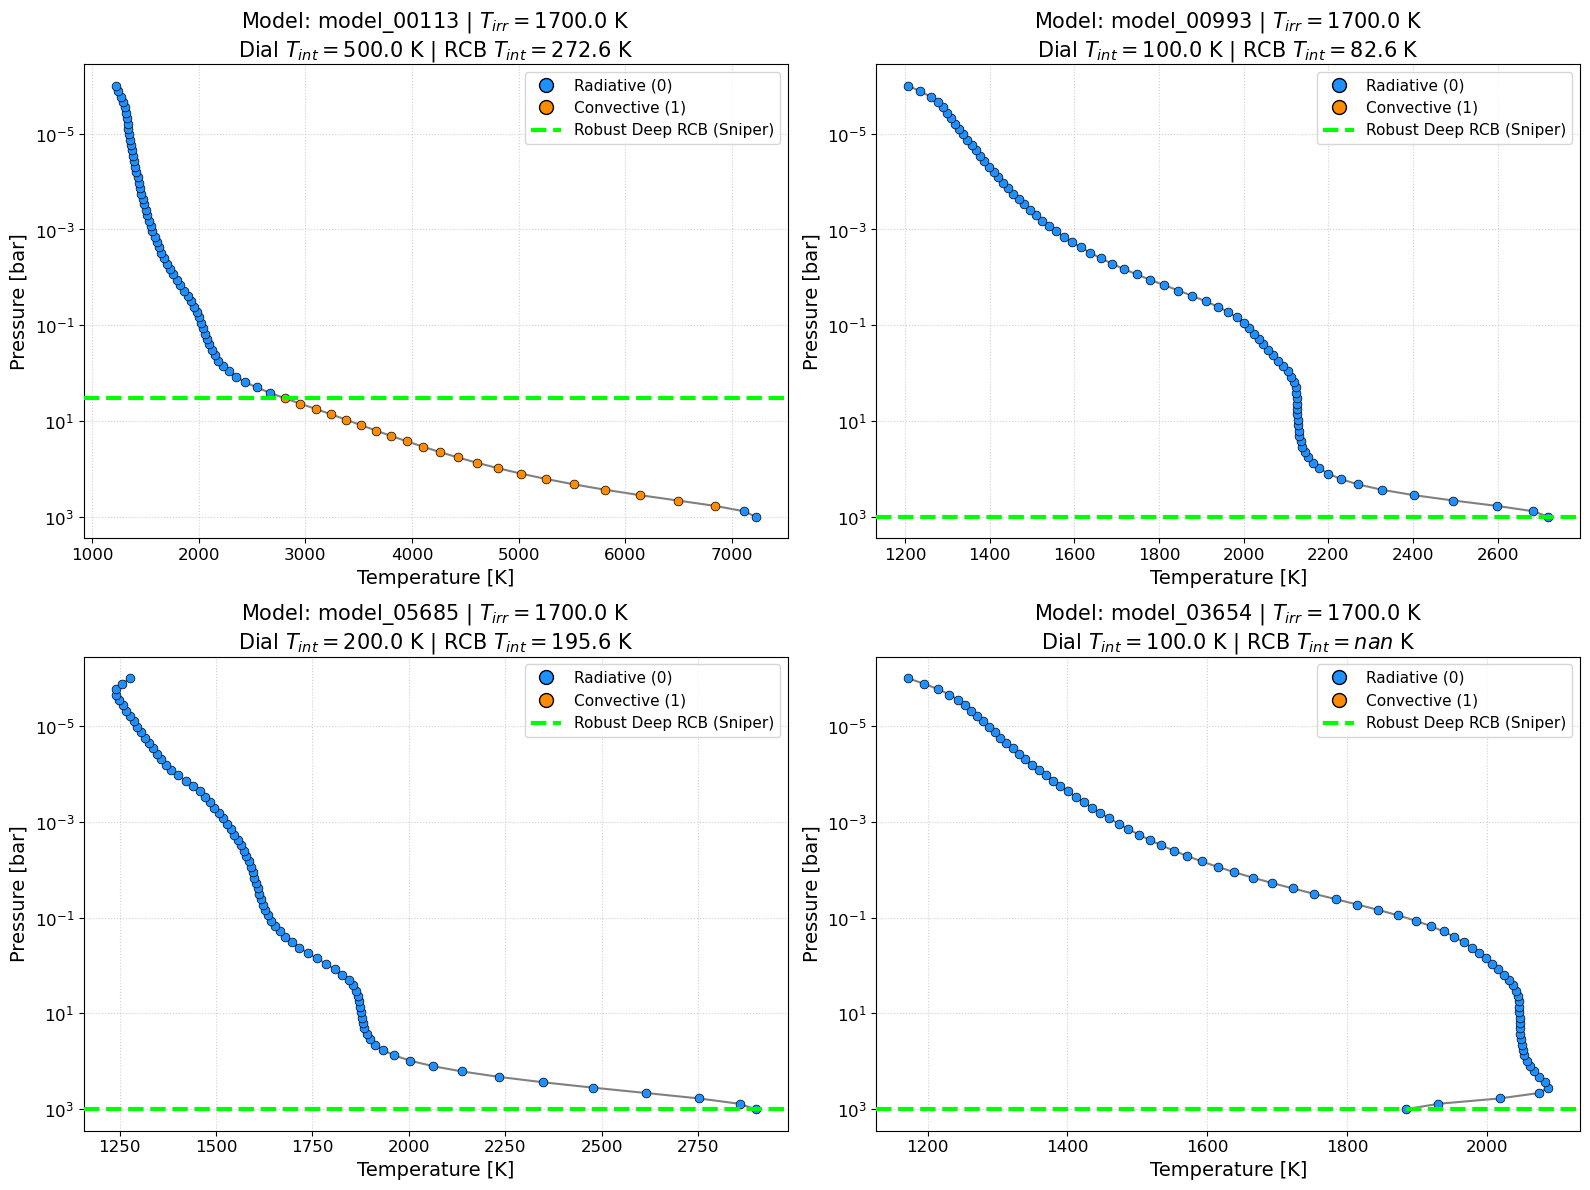

In [11]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

H5_PATH = "../outputs/master_grid_data.h5"
SIGMA_SB = 5.670374419e-8

def find_true_deep_rcb(is_conv_array, p_bar_array, p_threshold_bar=10.0, clear_space=3):
    """Direction-agnostic, robust scanner to find the True Deep RCB."""
    p_mask = p_bar_array >= p_threshold_bar
    if np.any(p_mask) and np.all(is_conv_array[p_mask] == 0):
        return np.max(p_bar_array[p_mask])

    bottom_idx = np.argmax(p_bar_array)
    step = 1 if bottom_idx == 0 else -1
    idx = bottom_idx
    n_layers = len(is_conv_array)
    
    def is_valid(i): return 0 <= i < n_layers
    
    while is_valid(idx):
        while is_valid(idx) and is_conv_array[idx] == 0: idx += step
        if not is_valid(idx): break
        while is_valid(idx) and is_conv_array[idx] == 1: idx += step
        if not is_valid(idx): break
            
        if step == 1:
            block = is_conv_array[idx : min(idx + clear_space, n_layers)]
        else:
            block = is_conv_array[max(0, idx - clear_space + 1) : idx + 1]
            
        if np.all(block == 0):
            return p_bar_array[idx - step]
    return np.nan

def plot_highly_irradiated_profiles_with_tints(h5_path):
    """
    Finds highly irradiated planets, plots their convective structure, 
    and annotates the titles with the requested Dial T_int vs achieved RCB T_int.
    """
    records = []
    
    print("Scanning grid for high T_irr models...")
    with h5py.File(h5_path, 'r') as f:
        for model_id in f.keys():
            if f"{model_id}/atmosphere_raw" in f and f"{model_id}/parameters" in f:
                params = f[model_id]['parameters'].attrs
                t_irr = params.get('T_irr', np.nan)
                t_dial = params.get('T_int_input_dial', np.nan)
                
                if not np.isnan(t_irr):
                    records.append({
                        'model_id': model_id, 
                        'T_irr': t_irr,
                        'T_dial': t_dial
                    })

    if not records:
        print("No models found. Check file path.")
        return

    df = pd.DataFrame(records)
    df_hot = df.sort_values(by='T_irr', ascending=False).reset_index(drop=True)
    
    # Pick 4 distinct models from the top of the irradiated list
    indices_to_plot = [0, 5, 10, 15] 
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    with h5py.File(h5_path, 'r') as f:
        for i, idx in enumerate(indices_to_plot):
            if idx >= len(df_hot):
                continue
            ax = axes[i]
            row = df_hot.iloc[idx]
            model_id = row['model_id']
            t_irr = row['T_irr']
            t_dial = row['T_dial']
            
            atm_grp = f[f"{model_id}/atmosphere_raw"]
            
            p_bar = atm_grp['_outputs_levels_pressure'][:] / 1e5
            t_k = atm_grp['_outputs_levels_temperature'][:]
            is_conv = atm_grp['_outputs_levels_is_convective'][:]
            rad_int = atm_grp['_outputs_levels_radiosity_internal'][:]
            
            # --- Apply the RCB Sniper ---
            p_rcb = find_true_deep_rcb(is_conv, p_bar)
            
            # --- Calculate T_int at the RCB ---
            t_int_rcb = np.nan
            if not np.isnan(p_rcb):
                idx_rcb = np.argmin(np.abs(p_bar - p_rcb))
                bottom_idx = np.argmax(p_bar)
                step = 1 if bottom_idx == 0 else -1
                
                # Average flux over the 3 clear radiative layers above RCB
                if step == 1:
                    slice_indices = list(range(idx_rcb, min(idx_rcb + 3, len(p_bar))))
                else:
                    slice_indices = list(range(max(0, idx_rcb - 2), idx_rcb + 1))
                
                rcb_flux = np.nanmean(rad_int[slice_indices])
                if rcb_flux > 0:
                    t_int_rcb = (rcb_flux / SIGMA_SB)**0.25
            
            # --- Plotting ---
            ax.plot(t_k, p_bar, color='gray', lw=1.5, zorder=1)
            
            rad_mask = (is_conv == 0)
            conv_mask = (is_conv == 1)
            
            ax.scatter(t_k[rad_mask], p_bar[rad_mask], color='dodgerblue', s=40, zorder=2, edgecolors='k', linewidths=0.5)
            ax.scatter(t_k[conv_mask], p_bar[conv_mask], color='darkorange', s=40, zorder=3, edgecolors='k', linewidths=0.5)
            
            if not np.isnan(p_rcb):
                ax.axhline(p_rcb, color='lime', linestyle='--', lw=3, zorder=4)

            # --- Formatting ---
            ax.set_yscale('log')
            ax.invert_yaxis()
            ax.set_xlabel("Temperature [K]", fontsize=14)
            ax.set_ylabel("Pressure [bar]", fontsize=14)
            
            # New Title Logic with T_dial and T_int_rcb
            title_str = (f"Model: {model_id} | $T_{{irr}} = {t_irr:.1f}$ K\n"
                         f"Dial $T_{{int}} = {t_dial:.1f}$ K | RCB $T_{{int}} = {t_int_rcb:.1f}$ K")
            ax.set_title(title_str, fontsize=15)
            ax.grid(True, linestyle=':', alpha=0.6)
            
            custom_lines = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue', markersize=10, markeredgecolor='k', label='Radiative (0)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, markeredgecolor='k', label='Convective (1)'),
                Line2D([0], [0], color='lime', lw=3, linestyle='--', label='Robust Deep RCB (Sniper)')
            ]
            ax.legend(handles=custom_lines, fontsize=11, loc='best')

    plt.tight_layout()
    plt.show()

# Run the plot
plot_highly_irradiated_profiles_with_tints(H5_PATH)

Scanning grid for Low T_int / High Radius models...


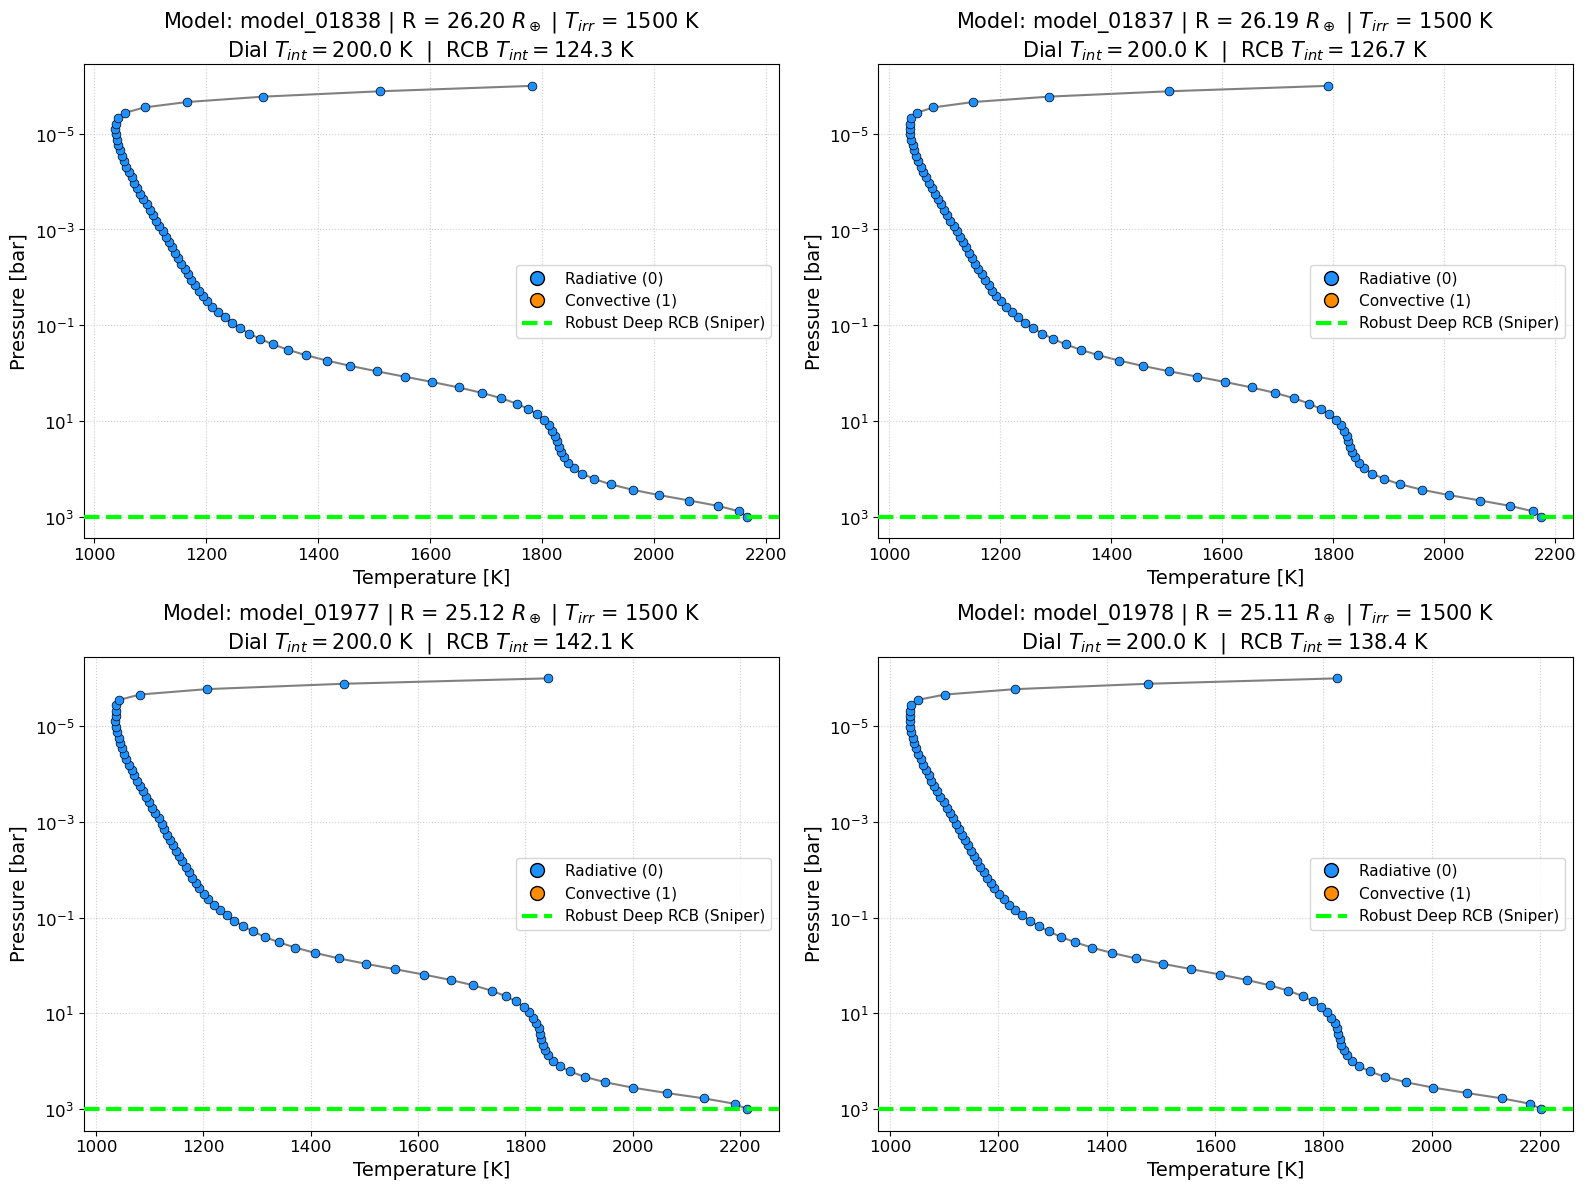

In [12]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

H5_PATH = "../outputs/master_grid_data.h5"
SIGMA_SB = 5.670374419e-8

def find_true_deep_rcb(is_conv_array, p_bar_array, p_threshold_bar=10.0, clear_space=3):
    """Direction-agnostic, robust scanner to find the True Deep RCB."""
    p_mask = p_bar_array >= p_threshold_bar
    if np.any(p_mask) and np.all(is_conv_array[p_mask] == 0):
        return np.max(p_bar_array[p_mask])

    bottom_idx = np.argmax(p_bar_array)
    step = 1 if bottom_idx == 0 else -1
    idx = bottom_idx
    n_layers = len(is_conv_array)
    
    def is_valid(i): return 0 <= i < n_layers
    
    while is_valid(idx):
        while is_valid(idx) and is_conv_array[idx] == 0: idx += step
        if not is_valid(idx): break
        while is_valid(idx) and is_conv_array[idx] == 1: idx += step
        if not is_valid(idx): break
            
        if step == 1:
            block = is_conv_array[idx : min(idx + clear_space, n_layers)]
        else:
            block = is_conv_array[max(0, idx - clear_space + 1) : idx + 1]
            
        if np.all(block == 0):
            return p_bar_array[idx - step]
    return np.nan

def plot_low_tint_high_radius_profiles(h5_path):
    """
    Finds models with low Dial T_int but exceptionally high planetary radius, 
    and plots their atmospheric T-P profiles to check for convergence anomalies.
    """
    records = []
    print("Scanning grid for Low T_int / High Radius models...")
    
    with h5py.File(h5_path, 'r') as f:
        for model_id in f.keys():
            # Ensure we have all the required data groups
            if f"{model_id}/atmosphere_raw" in f and f"{model_id}/parameters" in f and f"{model_id}/interior_raw" in f:
                params = f[model_id]['parameters'].attrs
                interior = f[model_id]['interior_raw'].attrs
                
                t_dial = params.get('T_int_input_dial', np.nan)
                r_tot_m = interior.get('R_total', np.nan)
                t_irr = params.get('T_irr', np.nan)
                
                if not np.isnan(t_dial) and not np.isnan(r_tot_m):
                    records.append({
                        'model_id': model_id, 
                        'T_dial': t_dial,
                        'R_total_Re': r_tot_m / 6357000.0, # Convert to Earth radii
                        'T_irr': t_irr
                    })
                    
    df = pd.DataFrame(records)
    
    if df.empty:
        print("No valid models found. Check file path or data completeness.")
        return
        
    # Filter for low T_int (adjust this threshold if you want strictly colder planets, e.g. 300K)
    df_low_t = df[df['T_dial'] <= 500].copy()
    
    if df_low_t.empty:
        print("No models found with T_int <= 500 K.")
        return
        
    # Sort by Radius descending to push the largest planets to the top
    df_low_t_high_r = df_low_t.sort_values(by='R_total_Re', ascending=False).reset_index(drop=True)
    
    # Pick the top 4 highly inflated models
    indices_to_plot = [0, 1, 2, 3] 
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    with h5py.File(h5_path, 'r') as f:
        for i, idx in enumerate(indices_to_plot):
            if idx >= len(df_low_t_high_r):
                continue
            
            ax = axes[i]
            row = df_low_t_high_r.iloc[idx]
            model_id = row['model_id']
            t_dial = row['T_dial']
            r_re = row['R_total_Re']
            t_irr = row['T_irr']
            
            atm_grp = f[f"{model_id}/atmosphere_raw"]
            
            # Extract Atmospheric arrays
            p_bar = atm_grp['_outputs_levels_pressure'][:] / 1e5
            t_k = atm_grp['_outputs_levels_temperature'][:]
            is_conv = atm_grp['_outputs_levels_is_convective'][:]
            rad_int = atm_grp['_outputs_levels_radiosity_internal'][:]
            
            # --- Apply the RCB Sniper ---
            p_rcb = find_true_deep_rcb(is_conv, p_bar)
            
            # --- Calculate T_int at the RCB ---
            t_int_rcb = np.nan
            if not np.isnan(p_rcb):
                idx_rcb = np.argmin(np.abs(p_bar - p_rcb))
                bottom_idx = np.argmax(p_bar)
                step = 1 if bottom_idx == 0 else -1
                
                if step == 1:
                    slice_indices = list(range(idx_rcb, min(idx_rcb + 3, len(p_bar))))
                else:
                    slice_indices = list(range(max(0, idx_rcb - 2), idx_rcb + 1))
                
                rcb_flux = np.nanmean(rad_int[slice_indices])
                if rcb_flux > 0:
                    t_int_rcb = (rcb_flux / SIGMA_SB)**0.25
            
            # --- Plotting ---
            ax.plot(t_k, p_bar, color='gray', lw=1.5, zorder=1)
            
            rad_mask = (is_conv == 0)
            conv_mask = (is_conv == 1)
            
            ax.scatter(t_k[rad_mask], p_bar[rad_mask], color='dodgerblue', s=40, zorder=2, edgecolors='k', linewidths=0.5)
            ax.scatter(t_k[conv_mask], p_bar[conv_mask], color='darkorange', s=40, zorder=3, edgecolors='k', linewidths=0.5)
            
            if not np.isnan(p_rcb):
                ax.axhline(p_rcb, color='lime', linestyle='--', lw=3, zorder=4)

            # --- Formatting ---
            ax.set_yscale('log')
            ax.invert_yaxis()
            ax.set_xlabel("Temperature [K]", fontsize=14)
            ax.set_ylabel("Pressure [bar]", fontsize=14)
            
            # Explicitly highlight the Radius and the T_ints in the title
            title_str = (f"Model: {model_id} | R = {r_re:.2f} $R_\\oplus$ | $T_{{irr}}$ = {t_irr:.0f} K\n"
                         f"Dial $T_{{int}} = {t_dial:.1f}$ K  |  RCB $T_{{int}} = {t_int_rcb:.1f}$ K")
            ax.set_title(title_str, fontsize=15)
            ax.grid(True, linestyle=':', alpha=0.6)
            
            custom_lines = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue', markersize=10, markeredgecolor='k', label='Radiative (0)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, markeredgecolor='k', label='Convective (1)'),
                Line2D([0], [0], color='lime', lw=3, linestyle='--', label='Robust Deep RCB (Sniper)')
            ]
            ax.legend(handles=custom_lines, fontsize=11, loc='best')

    plt.tight_layout()
    plt.show()

# Execute the plot
plot_low_tint_high_radius_profiles(H5_PATH)